In [ ]:

function get_parity(cfg::CZLPConfig, ϕ_cal; ode_kwargs...)
    cfg_parity = deepcopy(cfg)
    ket_ineg = (ket_0 - 1.0im * ket_1) / sqrt(2) #ket_pos = (ket_0 + ket_1) / sqrt(2)
    S_ZZ = Z ⊗ Z;

    cfg_parity.ψ0 = ket_ineg ⊗ ket_ineg #ket_pos ⊗ ket_pos
    ρ1 = simulation_czlp(cfg_parity; ode_kwargs...)[1][end] #    Had = Id ⊗ Hadamard

    ϕ_list =  [0.0:0.001:2π;]; #-ϕ1 .+ π/2 .+
    global_RZ = ϕ -> RZ(ϕ) ⊗ RZ(ϕ); #Had * global_RZ(ϕ) * ρ1 * dagger(Had * global_RZ(ϕ)) #(Phi_p ⊗ dagger(Phi_p))
    global_RX = x -> RX(x) ⊗ RX(x);
    θ = - cfg_parity.ϕ_RZ + ϕ_cal - π
    U = a -> global_RX(π/2) * global_RZ(a) * global_RX(5*π/4)

    Par_list = [real(expect(S_ZZ , U(ϕ) * global_RZ(θ) * ρ1 * dagger(U(ϕ) * global_RZ(θ)) ) ) for ϕ in ϕ_list];
    plot(ϕ_list, Par_list)
    return ϕ_list, Par_list #, ϕ_list[argmax(Par_list)]
end

function get_p_prob_
    Pr_p = ket_p ⊗ dagger(ket_p)
    Proj = Pr_p ⊗ Id + Id ⊗ Pr_p - Pr_p ⊗ Pr_p
    real(expect(Proj, ρ1))
end


function plot_cz_infidelity(infidelities;
    dir_name="/Users/goloshch/ColdAtoms_test/experiments/23_07_2025/results/", 
    file_name="plot_cz.png",
    title="Error budget for 2π pulse")

    keys_iF   = collect(keys(infidelities))
    keys_ordered = [
        "Total", 
        "Atom motion", 
        "Intermdeiate state decay", 
        "Rydberg state decay",
        "Laser noise"
        ]

    keys_final = [key for key in keys_ordered if key in keys_iF]
    values_final = [100*infidelities[key] for key in keys_ordered if key in keys_iF]

    p = bar(keys_final, values_final;
    xrotation=45,
    margin=10Plots.mm,
    ylabel="Infidelity, %", 
    title=title,
    label=nothing,
    dpi=300,
    size=(600, 600),
    xguidefontsize = 14,
    yguidefontsize = 14,
    xtickfontsize = 14,
    ytickfontsize = 14,
    color=RGBA(135.0/255,203.0/255,230.0/255,1.0)
    )

    savefig("$(dir_name)$(file_name)")

    display(p)

    return keys_final, values_final
end

In [ ]:

function plot_rydberg_infidelity(
    infidelities; 
    dir_name="/Users/goloshch/ColdAtoms_test/experiments/23_07_2025/results/", 
    file_name="plot.png",
    title="Error budget for 2π pulse",
    blue=true)

    red_color  = RGBA(207.0/255, 71.0/255, 80.0/255, 1.0)
    blue_color = RGBA(135.0/255,203.0/255,230.0/255,1.0)
    if blue
        color = blue_color 
    else 
        color = red_color
    end

    keys_iF   = collect(keys(infidelities))
    keys_ordered = [
        "Total", 
        "Atom motion", 
        "Intermdeiate state decay", 
        "Rydberg state decay",
        "Laser noise"
        ]

    keys_final = [key for key in keys_ordered if key in keys_iF]
    values_final = [100*infidelities[key] for key in keys_ordered if key in keys_iF]

    p = bar(keys_final, values_final;
    xrotation=45,
    margin=10Plots.mm,
    ylabel="Infidelity, %", 
    title=title,
    label=nothing,
    dpi=300,
    size=(600, 600),
    xguidefontsize = 14,
    yguidefontsize = 14,
    xtickfontsize = 14,
    ytickfontsize = 14,
    color=color
    )

    savefig("$(dir_name)$(file_name)")

    display(p)

    return keys_final, values_final
end



In [7]:
using NeutralAtoms
using DataFrames
using CSV
using DelimitedFiles  
using Plots  

In [8]:
df = DataFrame(readdlm("flattop_data.dat"), :auto);

In [9]:
corrX = -92.1
corrY = -88.7
x = df.x2 .+ corrX
y = df.x4 .+ corrY
z = 1 .- df.x6;

xx = round.(3.8*x, digits=2);
yy = round.(3.8*y, digits=2); #yy[1]
x_span = maximum(xx)-minimum(xx);
y_span = maximum(yy)-minimum(yy);
"""z0 = z .- 0.03
z_z = sqrt.( abs.(z0) ./ maximum(z0))
zz = z_z * 1.03 #1.02;"""
z0 = sqrt.(z) .- 0.168 #0.166
z_z = (z0) ./ maximum(z0)
zz = z_z * 1.05 ; #1.02;

In [10]:
len_x, len_y = 0,0
if (xx[1] == xx[31])
    len_x = 30
    len_y = 33
end;
n_max = 20
m_max = n_max
dx = x_span/len_x
dy = y_span/len_y
x_0 = [-x_span/2 : x_span/(len_x-1) : x_span/2;];
y_0 = [-y_span/2 : y_span/(len_y-1) : y_span/2;];

In [11]:
w = 2. ;
n_max = 21
cxy = decomposition_2d(xx, yy, zz, w,dx,dy);
c_xy = 1.05 * cxy[1:n_max,1:n_max]; # renormalization

##Моделирование##

In [13]:
include("../default.jl") #cfg, _ = get_default_configs();
if (false)
    bl_lsr_prms = cfg_HG.blue_laser_params
    w0 = w #bl_lsr_prms[2]
    zr = bl_lsr_prms[3]*(w0 / bl_lsr_prms[2])^2
    bl_lsr_prms = [bl_lsr_prms[1], w0, zr, 0.]  #[1.],[1.]] #
    println(bl_lsr_prms)
    cfg_HG.blue_laser_params = bl_lsr_prms
end

Основной атом

In [16]:
m = 86.9091835;     
T = 100.1;
cfg_HG, _ = get_default_configs();
cfg_HG.spontaneous_decay_intermediate = true;
cfg_HG.spontaneous_decay_rydberg = true;
cfg_HG.atom_params = [m, T]
println(cfg_HG.atom_params[2], " ",  cfg_HG.blue_laser_params["Ω"]/2π, " ", cfg_HG.red_laser_params["Ω"]/2π)

cfg_HG.blue_laser_params["type"] = "flattop" #"gauss" #
cfg_HG.blue_laser_params["coeffs_xy"] = c_xy;
cfg_HG.n_samples = 300; #

100.1 45.40655239059667 181.6262095623867


In [17]:
cfg_HG.blue_laser_params

Dict{String, Any} with 7 entries:
  "coeffs_xy" => [1.19061 -0.00432629 … -3.30497e-14 -2.58291e-15; 0.013834 0.0…
  "z0"        => 26.4555
  "n_sg"      => 1
  "θ"         => 0.0
  "w0"        => 2.0
  "Ω"         => 285.298
  "type"      => "flattop"

Target atoms

0.0%┣                                              ┫ 0/300 [00:00<00:-1, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:09<Inf:Inf, InfGs/it]
0.7%┣▎                                             ┫ 2/300 [00:12<59:41, 12s/it]
1.0%┣▌                                              ┫ 3/300 [00:16<39:15, 8s/it]
1.3%┣▋                                              ┫ 4/300 [00:22<35:36, 7s/it]
1.7%┣▉                                              ┫ 5/300 [00:28<34:57, 7s/it]
2.0%┣█                                              ┫ 6/300 [00:34<33:21, 7s/it]
2.3%┣█                                              ┫ 7/300 [00:40<32:15, 7s/it]
2.7%┣█▎                                             ┫ 8/300 [00:45<31:25, 6s/it]
3.0%┣█▍                                             ┫ 9/300 [00:51<30:54, 6s/it]
3.3%┣█▌                                            ┫ 10/300 [00:57<30:26, 6s/it]
3.7%┣█▊                                            ┫ 11/300 [01:02<29:52, 6s/it]
4.0%┣█▉                     

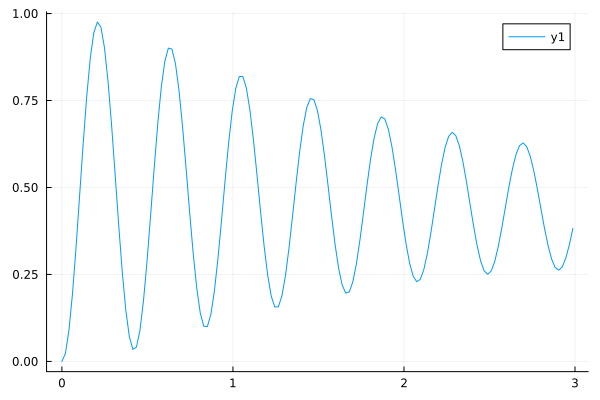

In [18]:
shift = [0., 1.7, 0.] 
#shift = [1.7, 0., 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = real(expect(ket_r ⊗ dagger(ket_r), ρ_mean));  
data = DataFrame(Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output17.csv", data)
plot(cfg_HG.tspan, Pr_HG) 

In [19]:
shift = [0., -1.7, 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = real(expect(ket_r ⊗ dagger(ket_r), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output_17.csv", data)
plot(cfg_HG.tspan, Pr_HG) ;

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:03<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:06<31:07, 6s/it]
1.0%┣▌                                              ┫ 3/300 [00:10<23:32, 5s/it]
1.3%┣▋                                              ┫ 4/300 [00:13<20:42, 4s/it]
1.7%┣▉                                              ┫ 5/300 [00:16<19:16, 4s/it]
2.0%┣█                                              ┫ 6/300 [00:19<18:22, 4s/it]
2.3%┣█                                              ┫ 7/300 [00:22<17:45, 4s/it]
2.7%┣█▎                                             ┫ 8/300 [00:25<17:15, 4s/it]
3.0%┣█▍                                             ┫ 9/300 [00:28<16:56, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:31<16:43, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:34<16:30, 3s/it]
4.0%┣█▉                     

Non-target atoms

In [20]:
function corr_detun(shift, cfg)
    d0 = cfg.detuning_params[1]
    dict = cfg.blue_laser_params
    lsr_prms = [dict["Ω"], dict["w0"], dict["z0"]]
    E0 = reconstruct_HG_field_2d(0.0,0.0,0.0, lsr_prms, c_xy)
    E = reconstruct_HG_field_2d(shift[1],shift[2],shift[3], lsr_prms, c_xy)
    #cfg.detuning_params = [d0, (abs(E)^2-abs(E0)^2)/(4*d0)]
    println("Ω = ", real(E) * lsr_prms[1]/(4π*d0)/2π, ", Δ = ", (abs(E)^2-abs(E0)^2)/(4*d0)/2π)
    return (abs(E)^2-abs(E0)^2)/(4*d0)
end;

Снизу

In [21]:
shift = [0., 5.1, 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = 1.0 .- real(expect(ket_1 ⊗ dagger(ket_1), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output51.csv", data)
plot(cfg_HG.tspan, Pr_HG) ;

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:03<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:06<29:23, 6s/it]
1.0%┣▌                                              ┫ 3/300 [00:09<22:02, 4s/it]
1.3%┣▋                                              ┫ 4/300 [00:12<19:29, 4s/it]
1.7%┣▉                                              ┫ 5/300 [00:15<18:14, 4s/it]
2.0%┣█                                              ┫ 6/300 [00:18<17:26, 4s/it]
2.3%┣█                                              ┫ 7/300 [00:21<16:52, 3s/it]
2.7%┣█▎                                             ┫ 8/300 [00:24<16:31, 3s/it]
3.0%┣█▍                                             ┫ 9/300 [00:27<16:20, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:30<16:02, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:33<15:42, 3s/it]
4.0%┣█▉                     

Сверху

In [22]:
shift = [0.0, -5.1, 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = 1.0 .- real(expect(ket_1 ⊗ dagger(ket_1), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output_51.csv", data)
plot(cfg_HG.tspan, Pr_HG) ;

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:03<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:06<27:40, 6s/it]
1.0%┣▌                                              ┫ 3/300 [00:09<21:04, 4s/it]
1.3%┣▋                                              ┫ 4/300 [00:11<18:44, 4s/it]
1.7%┣▉                                              ┫ 5/300 [00:14<17:31, 4s/it]
2.0%┣█                                              ┫ 6/300 [00:17<16:43, 3s/it]
2.3%┣█                                              ┫ 7/300 [00:20<16:12, 3s/it]
2.7%┣█▎                                             ┫ 8/300 [00:23<15:48, 3s/it]
3.0%┣█▍                                             ┫ 9/300 [00:25<15:26, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:28<15:11, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:31<15:02, 3s/it]
4.0%┣█▉                     

Снизу сбоку

In [23]:
shift = [3.4, 1.7, 0.] 
d_for_atom = 2π * 0.2
d = corr_detun(shift, cfg_HG)
d0 = cfg_HG.detuning_params[1]
 #(abs(E)^2-abs(E0)^2)/(4*d0)]
cfg_HG.detuning_params[2] += 2π*0 #d_for_atom

Ω = 0.0010352350274469681, Δ = -0.2933044265247256


-28.392143606817765

In [24]:
#shift = [3.4, 1.7, 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = 1.0 .- real(expect(ket_1 ⊗ dagger(ket_1), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output3417.csv", data)
plot(cfg_HG.tspan, Pr_HG) ;

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:03<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:06<28:49, 6s/it]
1.0%┣▌                                              ┫ 3/300 [00:09<21:21, 4s/it]
1.3%┣▋                                              ┫ 4/300 [00:11<18:48, 4s/it]
1.7%┣▉                                              ┫ 5/300 [00:14<17:28, 4s/it]
2.0%┣█                                              ┫ 6/300 [00:17<16:41, 3s/it]
2.3%┣█                                              ┫ 7/300 [00:20<16:07, 3s/it]
2.7%┣█▎                                             ┫ 8/300 [00:23<15:42, 3s/it]
3.0%┣█▍                                             ┫ 9/300 [00:25<15:26, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:28<15:10, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:31<14:58, 3s/it]
4.0%┣█▉                     

Сверху сбоку

In [25]:
shift = [3.4, -1.7, 0.] 
d_for_atom = 2π * 0.2
d = corr_detun(shift, cfg_HG)
d0 = cfg_HG.detuning_params[1]
 #(abs(E)^2-abs(E0)^2)/(4*d0)]
cfg_HG.detuning_params[2] += 2π*0.03 #d_for_atom

Ω = 0.012315626920364179, Δ = -0.2883703465702153


-28.20364804760238

In [26]:
#shift = [3.4, -1.7, 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = 1.0 .- real(expect(ket_1 ⊗ dagger(ket_1), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output34_17.csv", data)
plot(cfg_HG.tspan, Pr_HG) ;

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:03<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:05<26:55, 5s/it]
1.0%┣▌                                              ┫ 3/300 [00:08<20:18, 4s/it]
1.3%┣▋                                              ┫ 4/300 [00:11<17:59, 4s/it]
1.7%┣▉                                              ┫ 5/300 [00:14<16:50, 3s/it]
2.0%┣█                                              ┫ 6/300 [00:16<16:06, 3s/it]
2.3%┣█                                              ┫ 7/300 [00:19<15:40, 3s/it]
2.7%┣█▎                                             ┫ 8/300 [00:22<15:18, 3s/it]
3.0%┣█▍                                             ┫ 9/300 [00:25<15:01, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:28<14:48, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:30<14:37, 3s/it]
4.0%┣█▉                     

Слева сверху

In [27]:
shift = [-3.4, -1.7, 0.] 
d_for_atom = 2π * 0.2
d = corr_detun(shift, cfg_HG)
d0 = cfg_HG.detuning_params[1]
 #(abs(E)^2-abs(E0)^2)/(4*d0)]
cfg_HG.detuning_params[2] += 2π*0.01 #d_for_atom

Ω = 0.003348767900287077, Δ = -0.29297213504931247


-28.140816194530583

In [28]:
#shift = [-3.4, -1.7, 0.] 
ρ_mean, _ = simulation_one_shift(shift, cfg_HG) 
Pr_HG = 1.0 .- real(expect(ket_1 ⊗ dagger(ket_1), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output_34_17.csv", data)
plot(cfg_HG.tspan, Pr_HG) ;

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:02<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:05<25:08, 5s/it]
1.0%┣▌                                              ┫ 3/300 [00:08<18:49, 4s/it]
1.3%┣▋                                              ┫ 4/300 [00:10<16:40, 3s/it]
1.7%┣▉                                              ┫ 5/300 [00:13<15:32, 3s/it]
2.0%┣█                                              ┫ 6/300 [00:15<14:48, 3s/it]
2.3%┣█                                              ┫ 7/300 [00:18<14:20, 3s/it]
2.7%┣█▎                                             ┫ 8/300 [00:20<14:00, 3s/it]
3.0%┣█▍                                             ┫ 9/300 [00:23<13:43, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:25<13:29, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:28<13:18, 3s/it]
4.0%┣█▉                     

Слева снизу

In [29]:
shift = [-3.4, 1.7, 0.] 
d_for_atom = 2π * 0.2
d = corr_detun(shift, cfg_HG)
d0 = cfg_HG.detuning_params[1]
 #(abs(E)^2-abs(E0)^2)/(4*d0)]
cfg_HG.detuning_params[2] += -2π*0.07 #d_for_atom

Ω = 0.004446115180695171, Δ = -0.2926918974609948


-28.580639166033155

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:03<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:05<25:25, 5s/it]
1.0%┣▌                                              ┫ 3/300 [00:08<18:58, 4s/it]
1.3%┣▋                                              ┫ 4/300 [00:10<16:49, 3s/it]
1.7%┣▉                                              ┫ 5/300 [00:13<15:43, 3s/it]
2.0%┣█                                              ┫ 6/300 [00:15<15:00, 3s/it]
2.3%┣█                                              ┫ 7/300 [00:18<14:31, 3s/it]
2.7%┣█▎                                             ┫ 8/300 [00:20<14:10, 3s/it]
3.0%┣█▍                                             ┫ 9/300 [00:23<13:52, 3s/it]
3.3%┣█▌                                            ┫ 10/300 [00:25<13:37, 3s/it]
3.7%┣█▊                                            ┫ 11/300 [00:28<13:25, 3s/it]
4.0%┣█▉                     

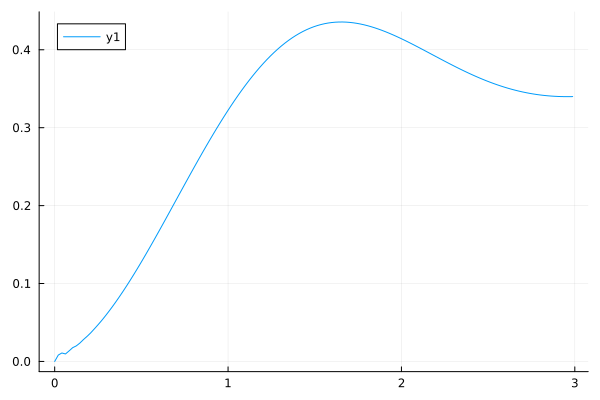

In [30]:
shift = [-3.4, 1.7, 0.] 
ρ_mean, _ = simulation_one_shift(shift,  cfg_HG) 
Pr_HG = 1.0 .- real(expect(ket_1 ⊗ dagger(ket_1), ρ_mean));  
data = DataFrame(    Column1 = cfg_HG.tspan,    Column2 = Pr_HG)
CSV.write("output_3417.csv", data)
plot(cfg_HG.tspan, Pr_HG) 

____________________________________